# Discrete Optimisation (N-Queens Problem)

### How does ARIEL EC module work?

The ARIEL EC (Evolutionary Computing) module works a bit different than other EAs (Evolutionary Algorithms). While other EAs represent the population as a simple list of individuals, here they the population is made as its own class, with a population being type of `list[Individuals]`. 

Similarly, in traditional EA architecture an individual is chosen for certain operators (for example parent selection) according to some criteria, put into a separate list and then given to the operator function. ARIEL works by giving individuals what we call `tags`. An individual has `tags` that can be toggled, which qualify it for any and all operations. The tag can be whether an individual can crossover or mutate in the future, but it can also show if it can enter the learning cycle.

The tags can be changed at all times, and default values for each tag can be given to more closely represent a traditional EA structure.

Additionally, ARIEL utilizes an SQL database to handle the variables and outputs of the code. This makes the code run faster, but it adds an extra step to the process.

This file demonstrates the process of initializing an EA class and running it for a simple problem, in our case, the Sphere function.

In [1]:
# Standard library
import random
from typing import Literal, cast

import matplotlib.pyplot as plt

# Third-party libraries
import numpy as np

# Function to show fitness landscape
from fitness_plot import plot_fit_per_gen

# Pretty little errors and progress bars
from rich.console import Console
from rich.traceback import install

# Local libraries
from ariel.ec import (
    EA,
    Crossover,
    EAOperation,
    EASettings,
    Individual,
    IntegerMutator,
    Population,
)

#### Visualisation for N-Queens board

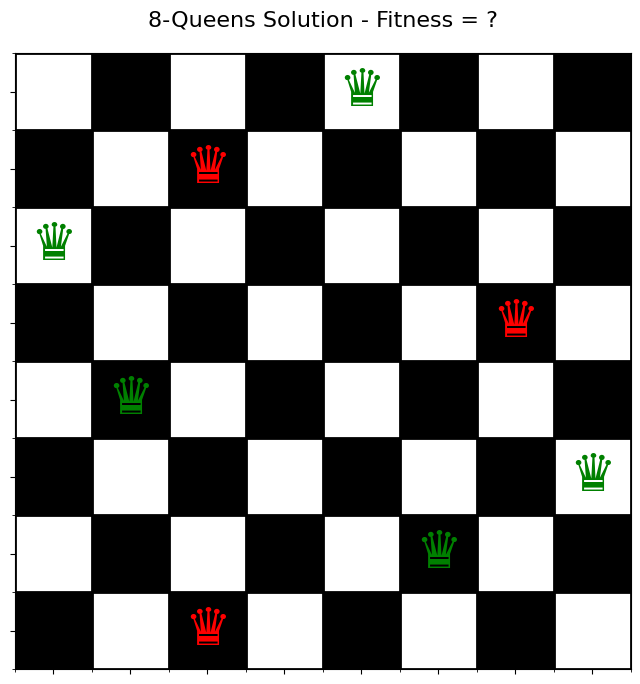

In [2]:
def visualize_solution(solution, fitness) -> None:
    """Visualize the N-Queens solution using matplotlib.

    - Attacking queens are red
    - non-attacking queens are green.
    """
    n = len(solution)

    # --- build checkered background ---
    board = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 1:
                board[i, j] = 0.7

    _fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(board, cmap="Greys", origin="upper")

    # --- detect which queens are in conflict ---
    attacking = [False] * n
    for r1 in range(n):
        c1 = solution[r1]
        for r2 in range(r1 + 1, n):
            c2 = solution[r2]
            same_col = (c1 == c2)
            same_diag = (abs(r1 - r2) == abs(c1 - c2))
            if same_col or same_diag:
                attacking[r1] = True
                attacking[r2] = True

    # --- draw queens with per-queen color ---
    for row, col in enumerate(solution):
        color = "red" if attacking[row] else "green"
        ax.text(col, row, "♛", fontsize=300 / n, ha="center", va="center", color=color)

    # --- grid / labels ---
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels([""] * n)
    ax.set_yticklabels([""] * n)

    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)

    plt.title(f"{n}-Queens Solution - Fitness = {fitness}", fontsize=16, pad=20)
    plt.show()


# Example: A valid 8-Queens solution
example_solution = [4, 2, 0, 6, 1, 7, 5, 2]
visualize_solution(example_solution, "?")


#### Define fitness function

In [3]:
# Define the fitness function
def evaluate_solution_n_queens(solution):
    """Calculate the fitness of an solution."""
    attacks = 0
    n = len(solution)
    for i in range(n):
        for j in range(i + 1, n):
            if solution[i] == solution[j] or abs(solution[i] - solution[j]) == abs(i - j):
                attacks += 1
                break  # Break out of the loop once an attack is found for the current queen

    # Fitness is equal to number of attacks
    return float(attacks)


def evaluate_ind(ind: Individual) -> float:
    """Evaluate an individual by calculating its fitness using the Ackley function."""
    return evaluate_solution_n_queens(cast("list[float]", ind.genotype))


@EAOperation
def evaluate_pop(population: Population) -> Population:
    """Evaluate a population by calculating the fitness of each individual."""
    for ind in population:
        if ind.requires_eval:
            ind.fitness = evaluate_ind(ind)
    return population

#### Initialize the global constants

In [4]:
# A seed is optional, but it helps with reproducibility
SEED = None  # e.g., 42

# The database has a few handling modes
    # "delete" will delete the existing database
    # "halt" will stop the execution if a database already exists
DB_HANDLING_MODES = Literal["delete", "halt"]

# Initialize RNG
RNG = np.random.default_rng(SEED)

# Initialize rich console and traceback handler
install()
console = Console()

### Initialize the EASettings class. 

The EASettings class acts as the handles the database and other parameters  

In [5]:
# Set config
config = EASettings(
    is_maximisation=False,
    db_handling="delete",
    target_population_size=100,
)

#### And just like that we have everything we need to get started. Now all we need to do define our evolutionary operators

Keep in mind that all operators in ARIEL have to work with the `Individual` and `Population` classes. You could define your own operators from scratch, but using the built in ones is easier.

In [ ]:
def create_individual(num_dims: int) -> Individual:
    ind = Individual()
    ind.genotype = np.random.permutation(num_dims).tolist()
    return ind


@EAOperation
def parent_selection(population: Population,
                     tournament_size: int = 5,
                     ) -> Population:
    """Tournament Selection."""
    # Ensure all individuals have a tags dict and reset parent-selection tag
    for ind in population:
        if ind.tags is None:
            ind.tags = {}
        ind.tags["ps"] = False

    # Decide how many parents we want (even number)
    num_parents = (len(population) // 2) * 2
    if num_parents == 0 and len(population) >= 2:
        num_parents = 2

    winners = []
    for _ in range(num_parents):
        # sample competitors with replacement
        competitors = [random.choice(population) for _ in range(tournament_size)]

        # pick best competitor depending on maximisation/minimisation
        if config.is_maximisation:
            winner = max(competitors, key=lambda ind: ind.fitness)
        else:
            winner = min(competitors, key=lambda ind: ind.fitness)

        winners.append(winner)

    # mark winners as parents
    for w in winners:
        w.tags["ps"] = True

    return population


@EAOperation
def crossover(population: Population) -> Population:
    """OX (Order) crossover for permutation genotypes."""
    parents = [ind for ind in population if ind.tags.get("ps", False)]
    np.random.default_rng()

    for idx in range(0, len(parents), 2):
        if idx + 1 >= len(parents):
            break  # odd parent out

        parent_i = parents[idx]
        parent_j = parents[idx + 1]

        genotype_i, genotype_j = Crossover.order_crossover(
            cast("list[int]", parent_i.genotype),
            cast("list[int]", parent_j.genotype),
        )
        # First child
        child_i = Individual()
        child_i.genotype = genotype_i
        child_i.tags = {"mut": True}
        child_i.requires_eval = True

        # Second child
        child_j = Individual()
        child_j.genotype = genotype_j
        child_j.tags = {"mut": True}
        child_j.requires_eval = True

        population.extend([child_i, child_j])

    return population


@EAOperation
def mutation(population: Population) -> Population:

    for ind in population:

        if ind.tags.get("mut", False):

            genes = cast("list[int]", ind.genotype)
            genes = IntegerMutator.swap(genes, mutation_probability=0.7)
            ind.genotype = genes.copy()

    return population


@EAOperation
def survivor_selection(population: Population) -> Population:

    tournament_size: int = 5

    # Decide how many parents we want (even number)
    pop_len = len(population)

    for _ in range(config.target_population_size):
        # Sample competitors with replacement
        pop_alive = [ind for ind in population if ind.alive is True]
        death_candidates = [random.choice(pop_alive) for _ in range(tournament_size)]

        # Pick best competitor depending on maximisation/minimisation
        if config.is_maximisation:
            about_to_be_killed_lol = min(death_candidates, key=lambda ind: ind.fitness)
        else:
            about_to_be_killed_lol = max(death_candidates, key=lambda ind: ind.fitness)

        about_to_be_killed_lol.alive = False

        pop_len -= 1
        if pop_len <= config.target_population_size:
            break

    return population

### Define evolutionary loop

Now that all our operators are done, we can define the evolutionary loop and run the algorithm


In [ ]:
def main(pop_size: int,
         num_queens: int,
         ) -> EA:
    """Entry point."""
    # Create initial population
    population_list = Population([create_individual(num_dims=num_queens) for _ in range(pop_size - 1)])
    population_list = evaluate_pop(population_list)

    # Create EA steps
    ops = [
        parent_selection(tournament_size=5),
        crossover(),
        mutation(),
        evaluate_pop(),
        survivor_selection(),
    ]

    # Initialize EA
    ea = EA(
        population_list,
        operations=ops,
        num_steps=100,
    )

    ea.run()

    best = ea.get_solution("best", only_alive=False)
    console.log(f"Best fitness: {best.fitness}")
    visualize_solution(best.genotype, best.fitness)

    return ea

[09:15:02] ⚠️  Database at                                                                                 ]8;id=240300;file://D:\University\ARIEL\FIx_docs\ariel\src\ariel\ec\ea.py\ea.py]8;;\:]8;id=794008;file://D:\University\ARIEL\FIx_docs\ariel\src\ariel\ec\ea.py#367\367]8;;\
           WindowsPath('d:/University/ARIEL/FIx_docs/ariel/docs/source/EA_intro/__data__/database.db') —           
           handling: 'delete' → deleting                                                                           

───────────────────────────────────────────────── EA Initialized ──────────────────────────────────────────────────

Output()

─────────────────────────────────────────────────── EA Finished ───────────────────────────────────────────────────

[09:15:22] Best fitness: 1.0                                                                       ]8;id=646140;file://C:\Users\johng\AppData\Local\Temp\ipykernel_25164\2652667041.py\2652667041.py]8;;\:]8;id=628890;file://C:\Users\johng\AppData\Local\Temp\ipykernel_25164\2652667041.py#26\26]8;;\

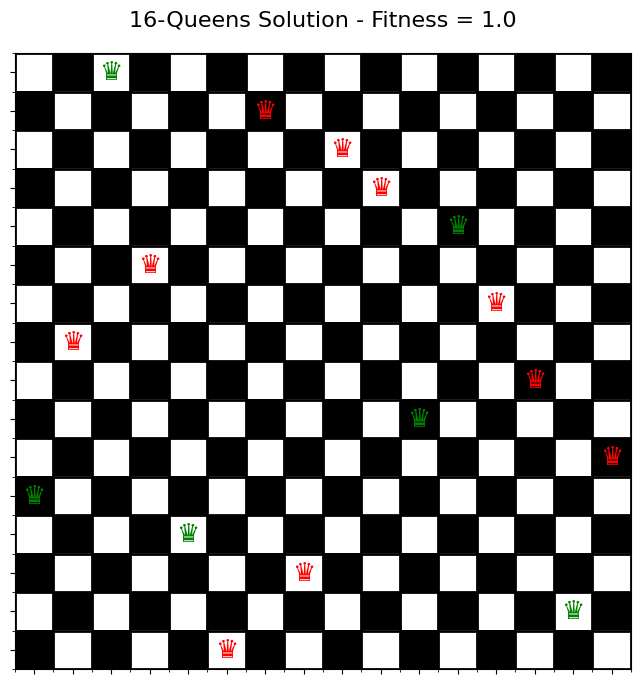

In [8]:
ea = main(pop_size=100,
          num_queens=16)

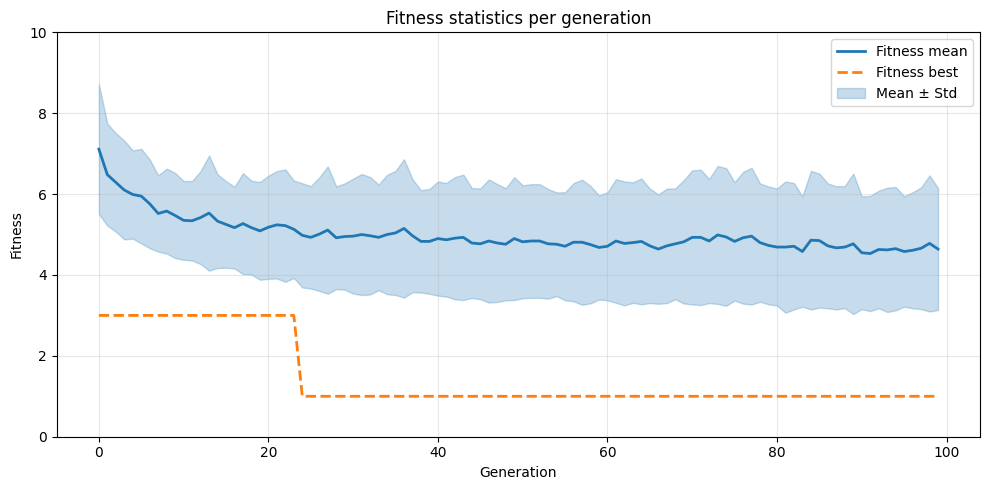

In [9]:
plot_fit_per_gen()